# Preprocess

In [36]:
from pipeline_preprocess import run_full_pipeline
resultats = run_full_pipeline(r"C:\TSQ\data\data1.csv")

df = resultats["df"]
df_PS = resultats["df_PS"]
df_PD = resultats["df_PD"]

df_SD = resultats["df_SD"]
df_SD_PS = resultats["df_SD_PS"]
df_SD_PD = resultats["df_SD_PD"]

df_BAI = resultats["df_BAI"]
df_TSQ = resultats["df_TSQ"]
df_TSQ_PD = resultats["df_TSQ_PD"]

df_EP = resultats["df_EP"]
df_EP_PD = resultats["df_EP_PD"]

df_16 = resultats["df_16"]
df_16_PD = resultats["df_16_PD"]
echelle1 = resultats["echelle1"]
echelle2 = resultats["echelle2"]

df_sub = resultats["df_sub"]

df_ZTPI = resultats["df_ZTPI"]
df_ZTPI_PD = resultats["df_ZTPI_PD"]

Nombre de lignes complètement vides : 0


# Analyse TSQ de Nortoff

# Pour participants sains 

In [37]:
from TSQ_scoring import calculer_scores_tsq  # adapte le nom du module si besoin

# --- Appel de la pipeline de scoring ---
df_scores = calculer_scores_tsq(df_TSQ, save_csv=False)

# --- Vérifications ---

score_cols = [
    'grand_score',
    'core_sz', 'core_md', 'core_ma', 'core_an', 'core_pt',
    'per_sz', 'per_md', 'per_ma', 'per_an', 'per_pt',
    'tot_sz', 'tot_md', 'tot_ma', 'tot_an', 'tot_pt',
]

# 1. Vérifier que toutes les colonnes de score existent
missing = [c for c in score_cols if c not in df_scores.columns]
assert not missing, f"Colonnes manquantes après scoring : {missing}"

# 2. Vérifier que les items ont bien été convertis en numérique (pas de texte résiduel)
items = [f"TSQ{i}" for i in range(1, 41)]
n_non_numeric = df_scores[items].isna().sum().sum()
print(f"Nombre total de valeurs NaN dans les items après conversion : {n_non_numeric}")

# 3. Vérifier que les scores sont bien dans [0, 1]
out_of_range = df_scores[score_cols][(df_scores[score_cols] < 0) | (df_scores[score_cols] > 1)]
n_out = out_of_range.dropna(how='all').shape[0]
print(f"Lignes avec un score hors [0,1] : {n_out}")

# 4. NaN par colonne de score (répondants avec items manquants sur une dimension)
print("\nNombre de NaN par colonne de score :")
print(df_scores[score_cols].isna().sum())

# 5. Statistiques descriptives
print("\nStatistiques descriptives :")
display(df_scores[score_cols].describe().T)

# 6. Aperçu
display(df_scores[['grand_score'] + score_cols[1:6]].head())

Nombre total de valeurs NaN dans les items après conversion : 0
Lignes avec un score hors [0,1] : 0

Nombre de NaN par colonne de score :
grand_score    0
core_sz        0
core_md        0
core_ma        0
core_an        0
core_pt        0
per_sz         0
per_md         0
per_ma         0
per_an         0
per_pt         0
tot_sz         0
tot_md         0
tot_ma         0
tot_an         0
tot_pt         0
dtype: int64

Statistiques descriptives :


,count,mean,std,min,25%,50%,75%,max
grand_score,154.0,0.237159,0.172579,0.0,0.088750,0.202500,0.361875,0.807500
core_sz,154.0,0.167086,0.153265,0.0,0.045312,0.137500,0.254687,0.781250
core_md,154.0,0.284601,0.213912,0.0,0.100000,0.257143,0.428571,0.842857
core_ma,154.0,0.341396,0.271244,0.0,0.100000,0.325000,0.525000,0.975000
core_an,154.0,0.282468,0.192668,0.0,0.121429,0.250000,0.426786,0.828571
core_pt,154.0,0.299567,0.201867,0.0,0.144444,0.277778,0.466667,0.988889
per_sz,154.0,0.260862,0.183749,0.0,0.100000,0.236364,0.400000,0.800000
per_md,154.0,0.191558,0.155203,0.0,0.063636,0.168182,0.286364,0.690909
per_ma,154.0,0.231674,0.175124,0.0,0.088889,0.188889,0.363889,0.811111
per_an,154.0,0.266450,0.190962,0.0,0.111111,0.227778,0.388889,0.833333


,grand_score,core_sz,core_md,core_ma,core_an,core_pt
1,0.3525,0.13750,0.485714,0.525,0.514286,0.466667
3,0.4250,0.31875,0.414286,0.725,0.464286,0.511111
5,0.3650,0.30000,0.300000,0.400,0.450000,0.488889
9,0.0200,0.00000,0.057143,0.000,0.014286,0.066667
10,0.0775,0.05000,0.057143,0.225,0.100000,0.077778


Nombre de lignes complètement vides : 0


KeyboardInterrupt: 

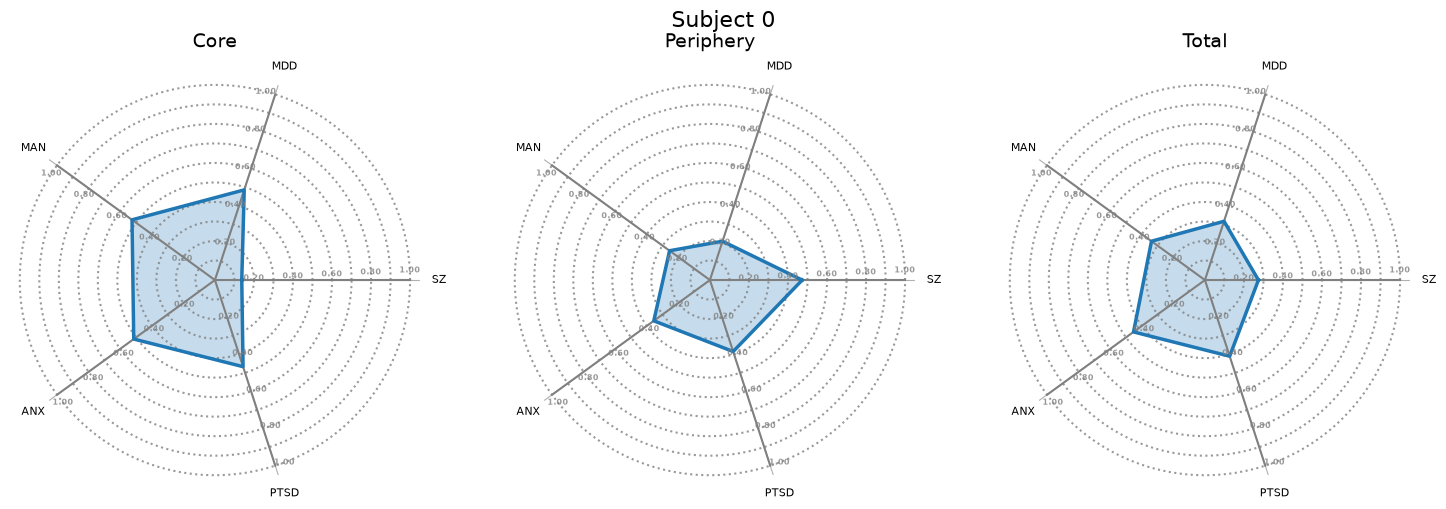

In [5]:
from pipeline_preprocess import run_full_pipeline
from TSQ_scoring import calculer_scores_tsq
from polar_plots import polar_plots

resultats = run_full_pipeline(r"C:\TSQ\data\data1.csv")
df_TSQ = resultats["df_TSQ"]

df_TSQ_scores = calculer_scores_tsq(df_TSQ)
polar_plots(df_TSQ_scores, output_dir="plots")


# Pour participants avec diag

In [6]:
from pipeline_preprocess import run_full_pipeline
from scoring_PD import calculer_scores_tsq
from polar_plots import polar_plots

resultats = run_full_pipeline(r"C:\TSQ\data\data1.csv")
df_TSQ = resultats["df_TSQ_PD"]

df_TSQ_scores = calculer_scores_tsq(df_TSQ_PD)
polar_plots(df_TSQ_scores, output_dir="plots_PD")

Nombre de lignes complètement vides : 0
33 graphiques générés dans le dossier 'plots_PD'.


In [14]:
from scoring_PD import calculer_scores_tsq  # adapte le nom du module si besoin

# --- Appel de la pipeline de scoring ---
df_scores = calculer_scores_tsq(df_TSQ_PD, save_csv=False)

# --- Vérifications ---

score_cols = [
    'grand_score',
    'core_sz', 'core_md', 'core_ma', 'core_an', 'core_pt',
    'per_sz', 'per_md', 'per_ma', 'per_an', 'per_pt',
    'tot_sz', 'tot_md', 'tot_ma', 'tot_an', 'tot_pt',
]

# 1. Vérifier que toutes les colonnes de score existent
missing = [c for c in score_cols if c not in df_scores.columns]
assert not missing, f"Colonnes manquantes après scoring : {missing}"

# 2. Vérifier que les items ont bien été convertis en numérique (pas de texte résiduel)
items = [f"TSQ{i}" for i in range(1, 41)]
n_non_numeric = df_scores[items].isna().sum().sum()
print(f"Nombre total de valeurs NaN dans les items après conversion : {n_non_numeric}")

# 3. Vérifier que les scores sont bien dans [0, 1]
out_of_range = df_scores[score_cols][(df_scores[score_cols] < 0) | (df_scores[score_cols] > 1)]
n_out = out_of_range.dropna(how='all').shape[0]
print(f"Lignes avec un score hors [0,1] : {n_out}")

# 4. NaN par colonne de score (répondants avec items manquants sur une dimension)
print("\nNombre de NaN par colonne de score :")
print(df_scores[score_cols].isna().sum())

# 5. Statistiques descriptives
print("\nStatistiques descriptives :")
display(df_scores[score_cols].describe().T)

# 6. Aperçu
display(df_scores[['grand_score'] + score_cols[1:6]].head())

Nombre total de valeurs NaN dans les items après conversion : 0
Lignes avec un score hors [0,1] : 0

Nombre de NaN par colonne de score :
grand_score    0
core_sz        0
core_md        0
core_ma        0
core_an        0
core_pt        0
per_sz         0
per_md         0
per_ma         0
per_an         0
per_pt         0
tot_sz         0
tot_md         0
tot_ma         0
tot_an         0
tot_pt         0
dtype: int64

Statistiques descriptives :


,count,mean,std,min,25%,50%,75%,max
grand_score,33.0,0.372955,0.185101,0.107500,0.212500,0.362500,0.532500,0.805000
core_sz,33.0,0.292045,0.214218,0.018750,0.087500,0.256250,0.437500,0.856250
core_md,33.0,0.417316,0.228844,0.028571,0.242857,0.414286,0.600000,0.885714
core_ma,33.0,0.505303,0.281303,0.000000,0.275000,0.575000,0.675000,1.000000
core_an,33.0,0.424459,0.170421,0.128571,0.271429,0.442857,0.557143,0.764286
core_pt,33.0,0.458249,0.209534,0.133333,0.255556,0.488889,0.611111,0.844444
per_sz,33.0,0.392011,0.171146,0.100000,0.281818,0.372727,0.527273,0.800000
per_md,33.0,0.306887,0.187000,0.018182,0.145455,0.309091,0.436364,0.790909
per_ma,33.0,0.377441,0.217120,0.055556,0.188889,0.333333,0.566667,0.822222
per_an,33.0,0.401347,0.199087,0.055556,0.233333,0.400000,0.577778,0.777778


,grand_score,core_sz,core_md,core_ma,core_an,core_pt
2,0.1750,0.05625,0.142857,0.675,0.271429,0.311111
4,0.5750,0.48750,0.885714,0.275,0.550000,0.844444
11,0.1925,0.06250,0.157143,0.750,0.271429,0.177778
13,0.4800,0.16875,0.657143,0.950,0.657143,0.555556
20,0.2950,0.28750,0.271429,0.350,0.385714,0.388889


In [15]:
df_scores['participant'] = range(len(df_scores))
print(len(df_scores))  # doit afficher 33

33


In [16]:
for _, row in df_scores.iterrows(): 
    print(f"--- Participant {row['participant']} ---")
    for col in score_cols:
        print(f"  {col}: {row[col]}")
    print()

--- Participant 0 ---
  grand_score: 0.175
  core_sz: 0.05625
  core_md: 0.14285714285714285
  core_ma: 0.675
  core_an: 0.2714285714285714
  core_pt: 0.3111111111111111
  per_sz: 0.18181818181818182
  per_md: 0.01818181818181818
  per_ma: 0.15555555555555556
  per_an: 0.15555555555555556
  per_pt: 0.105
  tot_sz: 0.10740740740740741
  tot_md: 0.06666666666666667
  tot_ma: 0.3153846153846154
  tot_an: 0.22608695652173913
  tot_pt: 0.16896551724137931

--- Participant 1 ---
  grand_score: 0.575
  core_sz: 0.4875
  core_md: 0.8857142857142857
  core_ma: 0.275
  core_an: 0.55
  core_pt: 0.8444444444444444
  per_sz: 0.4909090909090909
  per_md: 0.39090909090909093
  per_ma: 0.5777777777777777
  per_an: 0.5111111111111111
  per_pt: 0.48
  tot_sz: 0.4888888888888889
  tot_md: 0.5833333333333334
  tot_ma: 0.4846153846153846
  tot_an: 0.5347826086956522
  tot_pt: 0.593103448275862

--- Participant 2 ---
  grand_score: 0.1925
  core_sz: 0.0625
  core_md: 0.15714285714285714
  core_ma: 0.75
  co